Number of tiles contributing within the centre tile: 25


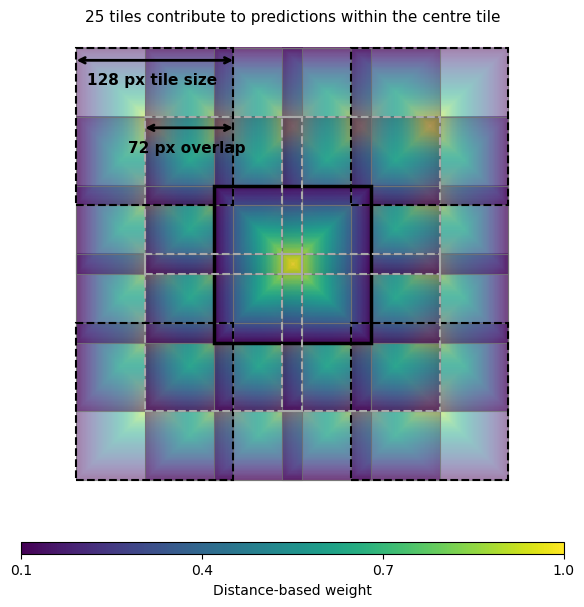

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


projectDir = "/Users/rfk471/Dropbox/elevation-canada"

experiment = "v1-0"


# ============================================================
# SETTINGS
# ============================================================

tile_size = 128
overlap = 72
stride = tile_size - overlap      # 56 pixels

min_weight = 0.1
max_weight = 1.0


# ============================================================
# CREATE DISTANCE-BASED WEIGHT MATRIX
# ============================================================

def create_tile_weights(
    tile_size=128,
    min_weight=0.1,
    max_weight=1.0
):
    """
    Create weights increasing linearly with distance from
    the nearest tile edge.

    Weight = min_weight at tile boundary
    Weight = max_weight at tile centre.
    """

    yy, xx = np.indices((tile_size, tile_size))

    # Distance to each edge
    dist_left = xx
    dist_right = tile_size - 1 - xx
    dist_bottom = yy
    dist_top = tile_size - 1 - yy

    # Distance to nearest edge
    dist_edge = np.minimum.reduce([
        dist_left,
        dist_right,
        dist_bottom,
        dist_top
    ])

    # Normalize from 0 to 1
    dist_norm = dist_edge / dist_edge.max()

    # Scale to desired weight range
    weights = (
        min_weight
        + dist_norm * (max_weight - min_weight)
    )

    return weights


weights = create_tile_weights(
    tile_size=tile_size,
    min_weight=min_weight,
    max_weight=max_weight
)


# ============================================================
# FIND ALL TILES THAT OVERLAP THE CENTRE TILE
# ============================================================

# The centre tile occupies:
#
# x = 0 ... 128
# y = 0 ... 128
#
# With a stride of 56 pixels, neighbouring tile origins are
# spaced at:
#
# ..., -112, -56, 0, 56, 112, ...
#
# All of these overlap the centre tile.

max_offset_steps = int(
    np.floor((tile_size - 1) / stride)
)

offset_steps = np.arange(
    -max_offset_steps,
    max_offset_steps + 1
)

offsets = offset_steps * stride


contributing_tiles = []

for dy in offsets:
    for dx in offsets:

        overlap_x = (
            dx < tile_size
            and dx + tile_size > 0
        )

        overlap_y = (
            dy < tile_size
            and dy + tile_size > 0
        )

        if overlap_x and overlap_y:
            contributing_tiles.append((dx, dy))


print(
    f"Number of tiles contributing within the centre tile: "
    f"{len(contributing_tiles)}"
)


# ============================================================
# FIGURE
# ============================================================

fig, ax2 = plt.subplots(
    figsize=(7, 7)
)


# ============================================================
# PLOT ALL NEIGHBOURING TILES
# ============================================================

# Four corner tiles
corner_tiles = {
    (offsets.min(), offsets.min()),
    (offsets.min(), offsets.max()),
    (offsets.max(), offsets.min()),
    (offsets.max(), offsets.max())
}
mid_tiles = {
    (offsets.min()+stride, offsets.min()+stride),
    (offsets.min()+stride, offsets.max()-stride),
    (offsets.max()-stride, offsets.min()+stride),
    (offsets.max()-stride, offsets.max()-stride),
}

for x0, y0 in contributing_tiles:

    # Centre tile is plotted separately below
    if x0 == 0 and y0 == 0:
        continue

    # Weight field
    ax2.imshow(
        weights,
        origin="lower",
        extent=[
            x0,
            x0 + tile_size,
            y0,
            y0 + tile_size
        ],
        cmap="viridis",
        vmin=min_weight,
        vmax=max_weight,
        interpolation="nearest",
        alpha=0.50
    )

    # Normal tile outline
    ax2.add_patch(
        patches.Rectangle(
            (x0, y0),
            tile_size,
            tile_size,
            fill=False,
            edgecolor="0.45",
            linewidth=0.8,
            alpha=0.8,
            zorder=5
        )
    )

    # Strong dashed outline around the four corner tiles
    if (x0, y0) in corner_tiles:
        ax2.add_patch(
            patches.Rectangle(
                (x0, y0),
                tile_size,
                tile_size,
                fill=False,
                edgecolor="black",
                linewidth=1.5,
                linestyle="--",
                zorder=20
            )
        )
    # Strong dashed outline around the four corner tiles
    if (x0, y0) in mid_tiles:
        ax2.add_patch(
            patches.Rectangle(
                (x0, y0),
                tile_size,
                tile_size,
                fill=False,
                edgecolor="darkgrey",
                linewidth=1.5,
                linestyle="--",
                zorder=20
            )
        )

# ============================================================
# PLOT CENTRE TILE
# ============================================================

ax2.imshow(
    weights,
    origin="lower",
    extent=[
        0,
        tile_size,
        0,
        tile_size
    ],
    cmap="viridis",
    vmin=min_weight,
    vmax=max_weight,
    interpolation="nearest",
    alpha=0.85
)


# Strong outline around centre tile
ax2.add_patch(
    patches.Rectangle(
        (0, 0),
        tile_size,
        tile_size,
        fill=False,
        edgecolor="black",
        linewidth=2.5,
        zorder=10
    )
)




# ============================================================
# FORMATTING
# ============================================================

ax2.set_title(
    "25 tiles contribute to predictions within the centre tile",
    fontsize=11
)

ax2.set_aspect("equal")

ax2.set_xticks([])
ax2.set_yticks([])


# Extent of complete neighbourhood
min_coord = offsets.min()
max_coord = offsets.max() + tile_size

padding = 15

ax2.set_xlim(
    min_coord - padding,
    max_coord + padding
)

ax2.set_ylim(
    min_coord - padding,
    max_coord + padding
)


# ============================================================
# COLORBAR
# ============================================================

sm = ScalarMappable(
    norm=Normalize(
        vmin=min_weight,
        vmax=max_weight
    ),
    cmap="viridis"
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax2,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    aspect=45
)

cbar.set_label(
    "Distance-based weight"
)

cbar.set_ticks([
    0.1,
    0.4,
    0.7,
    1.0
])



# ============================================================
# 72-PIXEL OVERLAP ANNOTATION
# ============================================================

ax2.annotate(
    "",
    xy=(offsets.min()-2, 230),
    xytext=(offsets.min()+tile_size+2, 230),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=2,
    ),
    zorder=25
)

ax2.text(
    (offsets.min()+12) / 2,
    220,
    "128 px tile size",
    ha="center",
    va="top",
    fontsize=11,
    color='black',
    fontweight='bold',
    zorder=25
)

ax2.annotate(
    "",
    xy=(offsets.min()+stride-2, 175),
    xytext=(offsets.min()+tile_size+2, 175),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=2,
    ),
    zorder=25
)

ax2.text(
    (offsets.min()+stride+12) / 2,
    165,
    "72 px overlap",
    ha="center",
    va="top",
    fontsize=11,
    color='black',
    fontweight='bold',
    zorder=25
)

ax2.axis('off')

fig.savefig(
    f"{projectDir}/figures/"
    f"{experiment}_tiling.png",
    dpi=300,
    bbox_inches="tight"
)